In [2]:
#Dataset with blur image is being detected
#tensorflow-->library keras(mnist)
import tensorflow as tf
import numpy as np 
import matplotlib.pyplot as plt

In [4]:
#we will load the dataset here

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [30]:
#now we will check our datasets
print("training images are:", x_train.shape)
print("training images are:", x_test.shape)
print("training images are:", y_train.shape)
print("training images are:", y_test.shape)

training images are: (60000, 28, 28, 1)
training images are: (10000, 28, 28, 1)
training images are: (60000,)
training images are: (10000,)


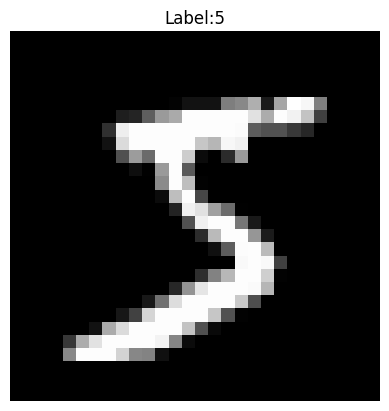

In [8]:
#we will display our first image, cmap tells us about the color
plt.imshow(x_train[0],cmap='gray')
plt.title("Label:"+str(y_train[0]))
plt.axis('off')
plt.show()

In [ ]:
#we will normailize our data--.So that nn follows range of 0 to 1 instead of the range of 0 to 255
x_train= x_train/255.0
x_test = x_test/255.0

In [10]:
#here we will reshape our data to fit the input shape of the CNN model
x_train = x_train.reshape(60000,28,28,1)
x_test = x_test.reshape(10000, 28,28,1)

In [11]:
#now, lets start building the CNN model
model = tf.keras.models.Sequential()

In [ ]:
#first convolutional layer
model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)))
#(3,3) is the kernel/filter size

c:\Users\HP\Desktop\College Training\.venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#first pooling layer-->reduces overfitting
model.add(tf.keras.layers.MaxPooling2D((2,2)))

In [14]:
#second convolutional layer
model.add(tf.keras.layers.Conv2D(64, (3,3), activation ='relu' ))

In [ ]:
#second pooling layer
model.add(tf.keras.layers.MaxPooling2D((2,2)))#pooling window of 2 * 2 size

In [ ]:
#now we will flatten our data to fit
model.add(tf.keras.layers.Flatten())

In [ ]:
#we will use our hidden layers with 64 neurons and relu activation function
model.add(tf.keras.layers.Dense(128, activation='relu'))

In [ ]:
#outpu layer with 10 neurons and softmax--->probability activation function20

model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [ ]:
#output model summary visualization
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#now we will compile the model after summarizing
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [22]:
#now we will train our model
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test),batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9538 - loss: 0.1540 - val_accuracy: 0.9845 - val_loss: 0.0471
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9854 - loss: 0.0468 - val_accuracy: 0.9866 - val_loss: 0.0381
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9894 - loss: 0.0327 - val_accuracy: 0.9906 - val_loss: 0.0287
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9925 - loss: 0.0237 - val_accuracy: 0.9878 - val_loss: 0.0348
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9937 - loss: 0.0191 - val_accuracy: 0.9907 - val_loss: 0.0275


In [23]:
#now we have arrived at the part of evaluating our model
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Loss: ", loss)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9907 - loss: 0.0275
Test Loss:  0.027503149583935738
Test Accuracy : 0.9907000064849854


In [24]:
#in the next step after evaluating our model, we will predict the digits
predictions = model.predict(x_test)
predicted_digit = np.argmax(predictions[0])

print("Predicted digit for the first test image: ", predicted_digit)
print("Actual label for the first test image: ", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted digit for the first test image:  7
Actual label for the first test image:  7


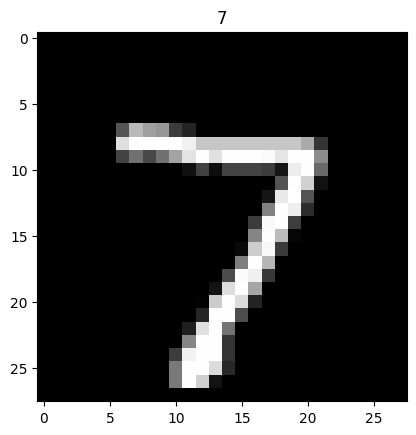

In [25]:
#after predicting the first test image, we will display it to see the result
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(str(predicted_digit))
plt.axis('on')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


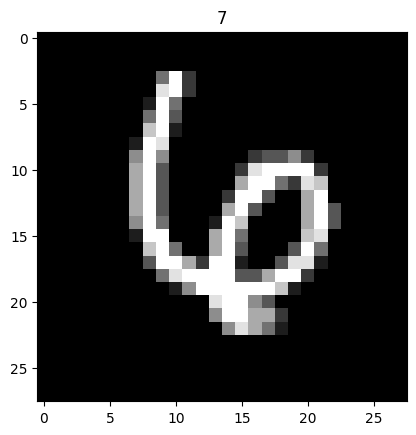

In [34]:
#lets test another image
index = 22
model.predict(x_test[index].reshape(1,28,28,1))
np.argmax(predictions)
plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(str(predicted_digit))
plt.axis('on')
plt.show()

In [28]:
#now lets save the model to reuse it and work on it for the next custom image dataset
model.save('g_606_developers.h5')